# Week 1 · Notebook 4 — Backtest and report: did it actually work?

You have a strategy and the engine's core. Today you run the strategy over **all**
of history and — the skill that separates real quant work from wishful thinking —
**report the result honestly** against the benchmark.

Two functions you build:
1. `total_return` — the headline: how much did we make?
2. `max_drawdown` — the honesty check: what was the worst loss along the way?

## 1. What a backtest is — you already built one, by hand

Yesterday, in NB3 §7, you looped `build_observation → sma_crossover_weights →
portfolio_return` across 10 days and watched a 1000 EGP balance move day by day.

A **backtest** is exactly that loop — the same three steps, in the same order —
just run across the *entire* history instead of 10 days. `run_backtest` does
nothing you haven't already done by hand. It just doesn't stop after 10 days.

## 2. Meet the universe

We'll trade a small, readable universe of five liquid Egyptian stocks — easier to
read in tables and charts than the full 35-stock list. Everything you write today
works unchanged on any universe size.

universe: ['COMI', 'HRHO', 'TMGH', 'SWDY', 'FWRY', 'ABUK'] | days of history: 1693


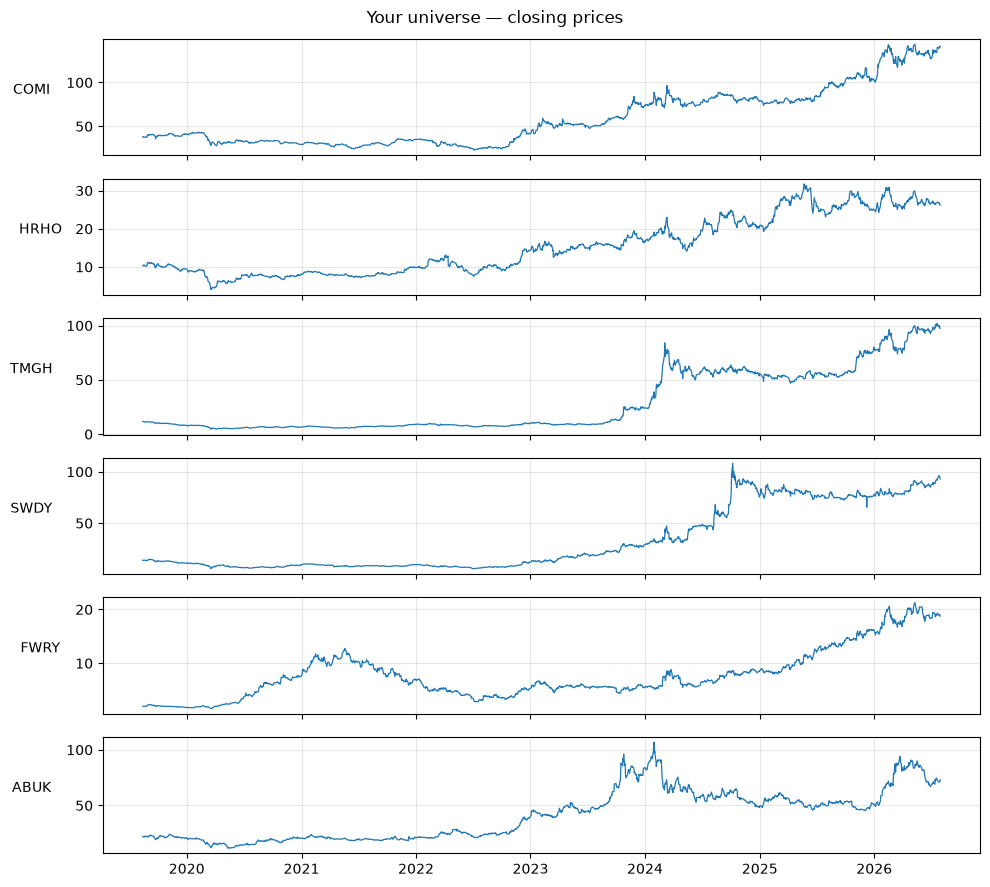

In [1]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np
import matplotlib.pyplot as plt
from tradinglab.data_feed import DataFeed
from tradinglab.simulator import PortfolioSimulator
from tradinglab.backtester import run_backtest
from tradinglab.strategies.sma import sma_crossover_weights
from tradinglab.charting import plot_price

# feed = DataFeed.from_dir('data/egx')
feed = DataFeed.from_dir('data/egx', symbols=['COMI', 'HRHO', 'TMGH', 'SWDY', 'FWRY', 'ABUK'])
sim = PortfolioSimulator(feed, commission=0.005)

print('universe:', feed.symbols, '| days of history:', feed.n_days)

# see what you're actually trading before running anything on it
fig, axes = plt.subplots(len(feed.symbols), 1, figsize=(10, 9), sharex=True)
for ax, sym, i in zip(axes, feed.symbols, range(feed.n_assets)):
    ax.plot(feed.dates, feed.close[:, i], linewidth=0.9)
    ax.set_ylabel(sym, rotation=0, labelpad=25)
    ax.grid(alpha=0.3)
plt.suptitle('Your universe — closing prices')
plt.tight_layout()
plt.show()

## 3. Run the backtest
Same strategy from yesterday. Same functions. Now over the whole dataset.

In [2]:
result = run_backtest(sim, lambda o: sma_crossover_weights(o, 9, 20), lookback=30)
print('the backtest returns an equity curve of length', len(result['portfolio']), 'days')
print('final portfolio value (starting at 1.0):', round(result['portfolio'][-1], 3))
print('final benchmark value (starting at 1.0):', round(result['benchmark'][-1], 3))

the backtest returns an equity curve of length 1662 days
final portfolio value (starting at 1.0): 2.547
final benchmark value (starting at 1.0): 7.143


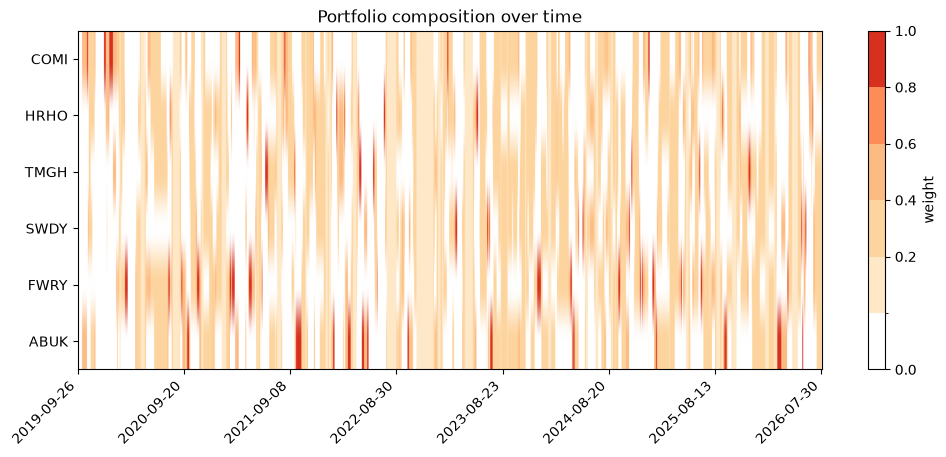

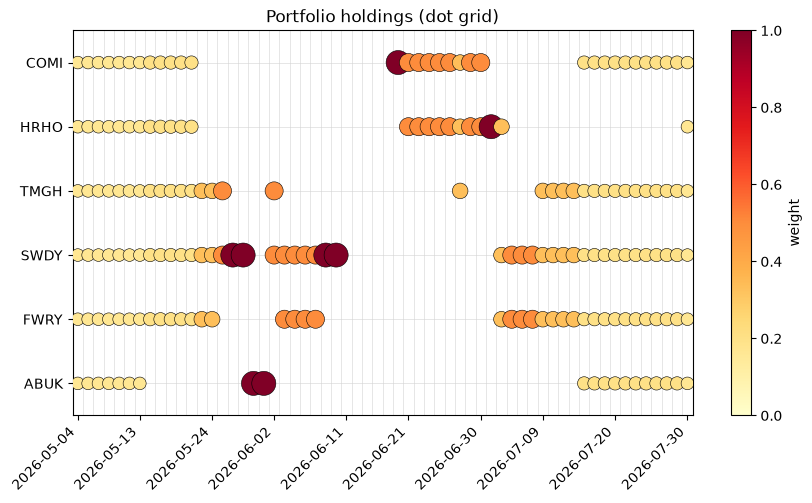

total trades: 1678
avg stocks held: 3.229241877256318


In [3]:
from tradinglab.charting import plot_portfolio_composition_discrete, plot_portfolio_dots, turnover_summary

plot_portfolio_composition_discrete(result['weights'], result['dates'], feed.symbols)
plt.show()

# zoom into the last 60 days for the precise dot view
plot_portfolio_dots(result['weights'][-60:], result['dates'][-60:], feed.symbols)
plt.show()


summary = turnover_summary(result['weights'])
print('total trades:', summary['total_trades'])
print('avg stocks held:', summary['avg_stocks_held'])

## 4. Function — `total_return`

The headline number: the total compounded gain over the whole period. `+0.5` means
+50%. Compounding matters — two +10% days make +21%, not +20%, because the second
gain applies to an already-grown balance.

**In:** an array of per-day returns. **Out:** one number.
**Hint:** `np.prod(1 + returns) - 1`.
**Done when:** the check passes.

In [4]:
def total_return(returns):
    # ---8<--- solution
    return float(np.prod(1 + np.asarray(returns)) - 1)
    # ---8<--- end

# 1000 EGP, two +10% days in a row: 1000 -> 1100 -> 1210. That's +21%, not +20%.
r = total_return(np.array([0.1, 0.1]))
assert abs(r - 0.21) < 1e-9
print(f'total_return correct ✓  (1000 EGP -> {1000*(1+r):.0f} EGP after two +10% days)')

total_return correct ✓  (1000 EGP -> 1210 EGP after two +10% days)


## 5. Function — `max_drawdown` — and a subtlety worth sitting with

The honesty check. A great final number can hide a terrifying ride. Max drawdown is
the **worst peak-to-trough fall** along the equity curve.

**Here's the part that trips people up:** drawdown is measured from your **peak**,
not from where you started. Picture 1000 EGP that grows to 2000 (up 100%), then
falls back to 1000 (down 50% from that peak). You're exactly breakeven overall —
and you *still* suffered a 50% drawdown, because for a while you really did have
2000 EGP, and watched half of it disappear.

**In:** per-day returns. **Out:** a number in [0, 1].
**Hint:** build the curve `np.cumprod(1+returns)`, track the running peak with
`np.maximum.accumulate`, take the largest `(peak-curve)/peak`.
**Done when:** the check passes.

In [5]:
def max_drawdown(returns):
    # ---8<--- solution
    curve = np.cumprod(1 + np.asarray(returns))
    peak = np.maximum.accumulate(curve)
    return float(np.max((peak - curve) / peak))
    # ---8<--- end

# 1000 -> 2000 (up 100%) -> 1000 (down 50% from the 2000 peak). Breakeven, but a
# real 50% drawdown happened along the way.
dd_returns = np.array([1.0, -0.5])
dd = max_drawdown(dd_returns)
assert abs(dd - 0.5) < 1e-9
balance = 1000 * np.cumprod(1 + dd_returns)
print('balance path (EGP):', balance.round(0))
print(f'ended exactly where it started ({balance[-1]:.0f} EGP) — but max drawdown = {dd:.0%}')
print('max_drawdown correct ✓')

balance path (EGP): [2000. 1000.]
ended exactly where it started (1000 EGP) — but max drawdown = 50%
max_drawdown correct ✓


## 6. See drawdown on your actual strategy
Not a toy example this time — your SMA strategy's real drawdown, over time.

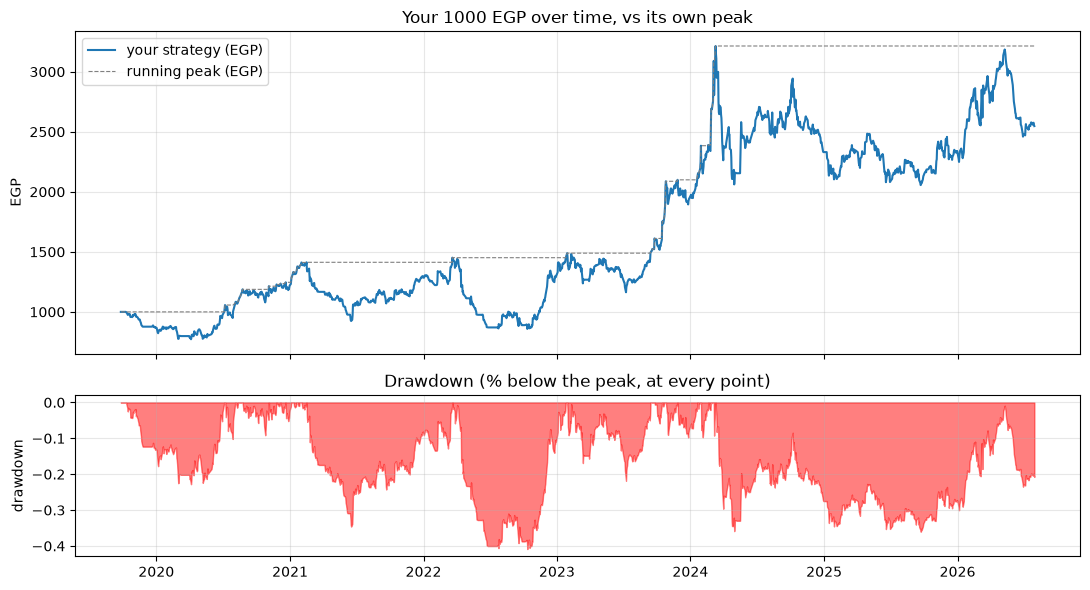

worst drawdown over the whole backtest: 40.9%
at its peak of 3214 EGP, that's a paper loss of about 1313 EGP


In [6]:
START_CAPITAL = 1000.0   # same anchor as the rest of the notebook

curve = result['portfolio'] * START_CAPITAL      # in EGP, not normalized to 1.0
peak = np.maximum.accumulate(curve)
drawdown_series = (peak - curve) / peak

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})
dates = result['dates']
ax1.plot(dates, curve, label='your strategy (EGP)')
ax1.plot(dates, peak, '--', color='gray', label='running peak (EGP)', linewidth=0.8)
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_title('Your 1000 EGP over time, vs its own peak')
ax1.set_ylabel('EGP')

ax2.fill_between(dates, -drawdown_series, 0, color='red', alpha=0.5)
ax2.set_title('Drawdown (% below the peak, at every point)')
ax2.set_ylabel('drawdown')
ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

worst_dd = max_drawdown(result['portfolio_returns'])
worst_dd_egp = peak.max() - peak.max() * (1 - worst_dd)   # how many EGP that drawdown cost, at its peak scale
print(f'worst drawdown over the whole backtest: {worst_dd:.1%}')
print(f"at its peak of {peak.max():.0f} EGP, that's a paper loss of about {worst_dd_egp:.0f} EGP")

computed by hand, using YOUR functions:
  total_return  = +154.7%
  max_drawdown  = 40.9%

now report() — same numbers, plus Sharpe and the chart:


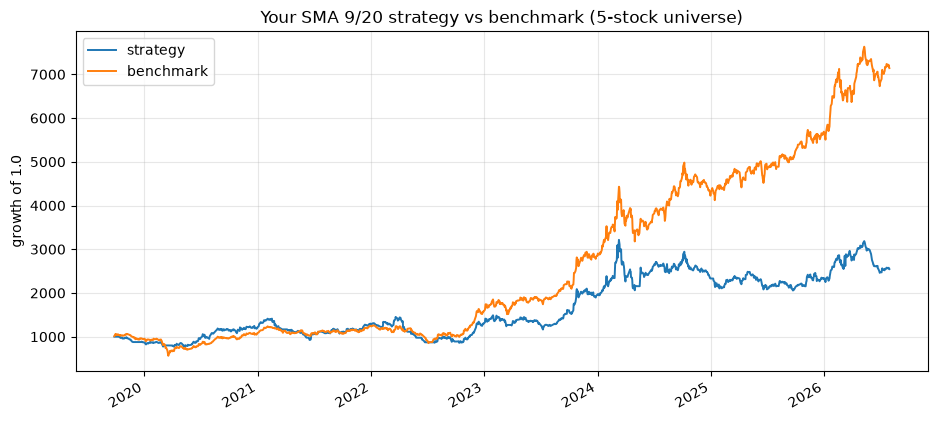

total return   : +154.7%
sharpe         : 0.63
max drawdown   : 40.9%
final value    : 2547.19   (benchmark 7143.40)
beat benchmark : no
                 you lost to the benchmark by 4,596 EGP


In [7]:
r = result['portfolio_returns']
print('computed by hand, using YOUR functions:')
print(f'  total_return  = {total_return(r):+.1%}')
print(f'  max_drawdown  = {max_drawdown(r):.1%}')

from tradinglab.report import report
print('\nnow report() — same numbers, plus Sharpe and the chart:')
report(result, title='Your SMA 9/20 strategy vs benchmark (5-stock universe)', start_capital=START_CAPITAL)



## 8. Wait — which benchmark did we use?

So far "the benchmark" has meant equal-weight-of-these-5-stocks — a fair comparison,
but not the one most people mean when they say "beat the market." Let's check
against the **real EGX30 index** instead, using the exact same strategy, unchanged.

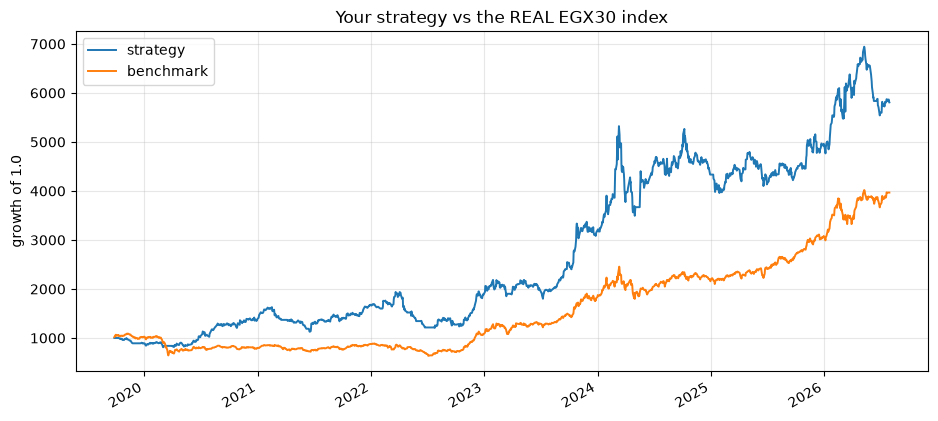

total return   : +480.7%
sharpe         : 1.05
max drawdown   : 37.8%
final value    : 5807.42   (benchmark 3967.15)
beat benchmark : YES
                 you beat the benchmark by 1,840 EGP


In [8]:
sim_real = PortfolioSimulator(feed, benchmark='egx30')
result_real = run_backtest(sim_real, lambda o: sma_crossover_weights(o, 9, 20), lookback=30)
report(result_real, title='Your strategy vs the REAL EGX30 index', start_capital=1000.0)

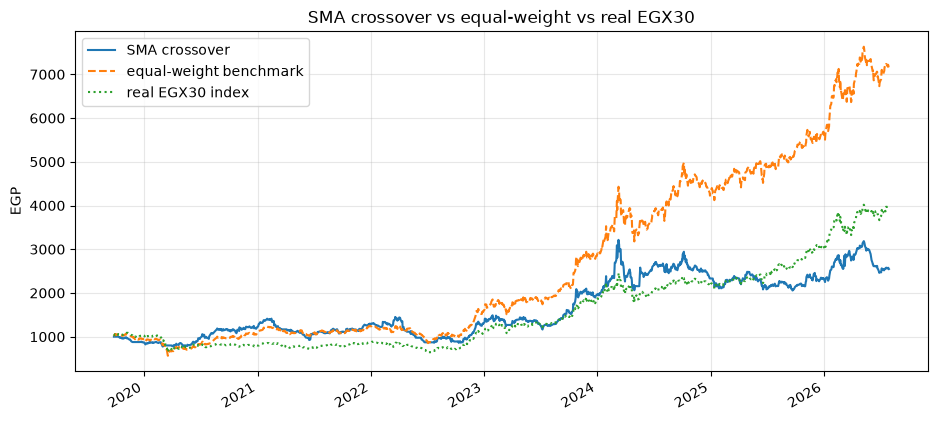

In [9]:
import pandas as pd
from tradinglab.data_feed import load_egx30_returns

egx30_full = load_egx30_returns('data/egx30.csv', feed.dates)
START = 1000.0

if egx30_full is not None:
    # match EVERY date in `dates` to its egx30 value by LABEL, not position —
    # guaranteed to line up, regardless of what produced `dates`/`result`
    egx30_series = pd.Series(egx30_full, index=feed.dates)
    egx30_matched = egx30_series.loc[dates].to_numpy()
    egx30_curve = np.cumprod(1 + egx30_matched) * START

    plt.figure(figsize=(11, 5))
    plt.plot(dates, result['portfolio'] * START, label='SMA crossover')
    plt.plot(dates, result['benchmark'] * START, label='equal-weight benchmark', linestyle='--')
    plt.plot(dates, egx30_curve, label='real EGX30 index', linestyle=':')
    plt.legend(); plt.grid(alpha=0.3); plt.ylabel('EGP')
    plt.title('SMA crossover vs equal-weight vs real EGX30')
    plt.gcf().autofmt_xdate()
    plt.show()
else:
    print("data/egx30.csv not found or doesn't cover this range — skipping the real-index line.")

### The catch

Your strategy beat EGX30 — but so would simply *holding* these 5 stocks and never
trading at all (check `result['portfolio']` from earlier vs this one). That means
the win came from *which stocks you picked*, not from the SMA rule itself. The
trading rule actually cost you money compared to doing nothing.

This is worth sitting with: a good final number can hide the wrong conclusion if
you don't compare against the right baseline.

## 9. Read this honestly

On this universe, a simple trend rule is not a money machine — and that's the
honest truth, not a failure of your code. Sitting with that is the whole point:
next week you'll try to beat the benchmark with prediction (and discover why
that's hard), then with a learning agent.

**Graduate** `total_return` and `max_drawdown` into `src/tradinglab/metrics.py`,
then:
```
uv run pytest week1/tests/
```
You've now done the complete loop of quant work: build → backtest → report →
judge honestly, in real money the whole way through.